In [2]:
## Load libraries
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely
from shapely.geometry import Polygon
import math
import pyproj

In [3]:
## Global parameters

PROJECT_CRS = "EPSG:4326"  # Project canonical CRS
METRIC_CRS = "EPSG:3763"   # CRS for planar projection
HEX_SIZE = 500             # Hexagon size in meters (approximate center-to-center distance)

In [5]:
## Load study area
area = gpd.read_file("/data/amp.json")
print(area.crs)
assert area.crs is not None, "Study area has no CRS defined"

## Reproject study area
area_proj = area.to_crs(METRIC_CRS)
print(area_proj.crs)

EPSG:4326
EPSG:3763


In [6]:
## Hexagonal grid generation

# Study area bounding box
minx, miny, maxx, maxy = area_proj.total_bounds

# Hexagon geometric parameters
dx = HEX_SIZE * 3**0.5
dy = HEX_SIZE * 1.5

# Hexagon generation
hexes = []

y = miny
row = 0
while y < maxy + dy:
    x = minx + (dx / 2 if row % 2 else 0)
    while x < maxx + dx:
        hexagon = Polygon([
            (x + HEX_SIZE * math.cos(math.radians(angle)),
             y + HEX_SIZE * math.sin(math.radians(angle)))
            for angle in range(0, 360, 60)
        ])
        hexes.append(hexagon)
        x += dx
    y += dy
    row += 1

grid_hex = gpd.GeoDataFrame(geometry=hexes, crs=METRIC_CRS)

## Spatial clipping of the grid
grid_hex_clip = gpd.overlay(grid_hex, area_proj, how="intersection")

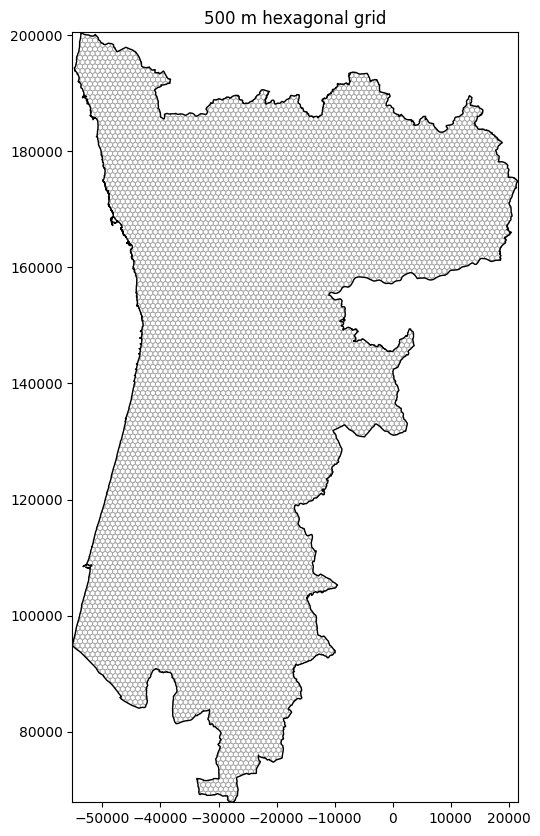

In [7]:
## Plot grid
minx, miny, maxx, maxy = area_proj.total_bounds

fig, ax = plt.subplots(figsize=(8, 10))

area_proj.boundary.plot(ax=ax, color="black", linewidth=1)
grid_hex_clip.plot(ax=ax, edgecolor="gray", facecolor="none", linewidth=0.3)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_aspect("equal")
ax.set_title("500 m hexagonal grid")

plt.show()

In [8]:
## Centroid calculation
grid_hex_clip["centroid"] = grid_hex_clip.geometry.centroid
points_proj = grid_hex_clip.set_geometry("centroid")
print(points_proj.geom_type.unique())

<StringArray>
['Point']
Length: 1, dtype: str


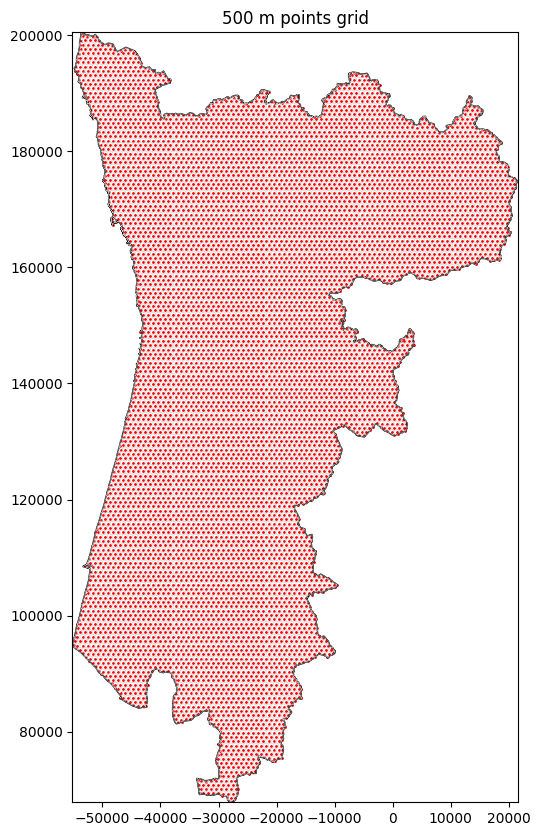

In [10]:
## Plot points
fig, ax = plt.subplots(figsize=(8, 10))

area_proj.boundary.plot(ax=ax, color="black", linewidth=1)
grid_hex_clip.boundary.plot(ax=ax, color="lightgray", linewidth=0.3)
points_proj.plot(ax=ax, color="red", markersize=1)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_aspect("equal")
ax.set_title("500 m points grid")

plt.show()

In [11]:
## Conversion to GeoDataFrame and reprojection to EPSG:4326
points_proj = gpd.GeoDataFrame(
    grid_hex_clip.drop(columns="geometry"),
    geometry="centroid",
    crs=METRIC_CRS
)

points_proj = points_proj.rename_geometry("geometry")
print(points_proj.geom_type.unique())
print(points_proj.crs)           

points_proj = points_proj.to_crs(PROJECT_CRS)
print(points_proj.crs)

points_proj["lon"] = points_proj.geometry.x
points_proj["lat"] = points_proj.geometry.y

## Assignment of spatial identifier (point_id)
points = points_proj.reset_index(drop=True)
points["point_id"] = points.index

points = points[["point_id", "geometry", "lat", "lon"]]
points = points.set_geometry("geometry")

<StringArray>
['Point']
Length: 1, dtype: str
EPSG:3763
EPSG:4326


In [12]:
## Basic spatial validations
# valid geometries
assert points.is_valid.all(), "There are invalid geometries in the points"

# non-empty geometries
assert (~points.is_empty).all(), "There are empty geometries"

n_hex = len(grid_hex_clip)
n_points = len(points)

assert n_hex == n_points, "Mismatch between hexagons and centroids"

print(f"Total number of hexagons: {n_hex}")

# total covered area (approximate)
total_area_km2 = grid_hex_clip.area.sum() / 1e6
print(f"Total covered area (km²): {total_area_km2:.2f}")

# approximate density
print(f"Density (hex/km²): {n_hex / total_area_km2:.1f}")

Total number of hexagons: 8299
Total covered area (km²): 5132.68
Density (hex/km²): 1.6


In [ ]:
## Save
out_path = "/results/gpoints_hex_500m_wgs84.geojson"
points.to_file(out_path, driver="GeoJSON")